# Caso 7 - Modelo ANOVA para establecer diferencias significativas en una y dos variables categóricas
En este caso de estudio se analiza información proveniente de una encuesta aplicada a jugadores de videojuegos, con el propósito de identificar si existen diferencias significativas en los niveles de comportamiento violento reportado. Para ello, se emplean modelos estadísticos como el ANOVA de un factor y el ANOVA de dos factores, evaluando el efecto de variables como el tiempo de juego, el género y la edad de los jugadores, tanto de forma individual como combinada. La implementación de estos modelos se realiza utilizando las librerías scipy.stats y statsmodels en Python, lo que permite aplicar distintos enfoques para el análisis de varianza y fortalecer la interpretación estadística de los resultados.

## Resultado previsto de aprendizaje
Al finalizar este caso, el estudiante será capaz de:
- Verificar y validar los supuestos de normalidad y homogeneidad de varianzas para aplicar modelos ANOVA.
- Aplicar correctamente un ANOVA de un factor para establecer diferencias en un los tipos de datos
- Implementar un ANOVA de dos factores para identificar efectos individuales e interactivos entre variables 

## Contexto del Problema
- Usted forma parte de un equipo de investigación interesado en comprender los factores que podrían estar asociados a comportamientos violentos en personas que consumen videojuegos de forma regular. A partir de una base de datos obtenida por encuesta, se plantea la necesidad de evaluar si el tiempo dedicado a jugar videojuegos está relacionado con niveles más altos de comportamiento violento, y si este patrón varía dependiendo del género y la edad del jugador. El análisis busca determinar si estas variables explican diferencias significativas en las respuestas, y si existe una interacción entre ellas que modifique su efecto. Esta información puede ser útil para diseñar estrategias de prevención o educación enfocadas en el uso saludable de los videojuegos.

Iniciamos importando las librerías que usaremos

In [3]:
import numpy as np # linear algebra
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro
from scipy.stats import levene

Importamos nuestros datos

In [4]:
video_games = pd.read_csv('data/Videogames_Hours_Agression.csv')
video_games

,Timestamp,What is your age?,Gender,Class,City/ Residencial status,Type of Family,What type of video games do you typically play?,Name the video game you usually play,How many hours do you play Video Games in a day?,"How much time do you play ""violent"" video games specifically?",...,there are people who pushed me so far that we begin fighting,"I know that some so called ""friends"" talk about me behind my back",My friends say that I am a bit argumentative,Sometimes I lose temper for no good reason,I get into fights a little more than a normal person,sometimes I can not control the feeling to hit another person,I sometimes get too much jealous from people,I dont know why sometimes I feel bitter about things,"Have you ever been involved in delinquent behaviour? like stealing, breaking things of others",Do you believe that playing violent video games can lead to aggressive behavior in real life?
0,7-11-2023 22:16:49,20,male,12th,Lahore,joint,action,Pubg,more than 3 hour,more than 2 hour,...,Agree,Agree,Agree,Strongly disagree,Disagree,NaN,NaN,NaN,no,yes
1,7-11-2023 23:01:27,18,male,11th,Lahore,joint,action,Pubg,more than 3 hour,more than 2 hour,...,Agree,Agree,Strongly agree,Agree,Agree,Agree,Neither agree nor disagree,Disagree,yes,yes
2,7-11-2023 23:11:33,16,male,11th,Lahore,nuclear,action,PUBG,more than 1 hour,more than 1 hour,...,Disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Disagree,Strongly disagree,Strongly disagree,Disagree,yes,yes
3,7-11-2023 23:12:33,19,female,12th,Lahore,nuclear,word connect,word connect,less than 1 hour,less than 1 hour,...,Strongly disagree,Agree,Disagree,Disagree,Disagree,Disagree,Strongly disagree,Disagree,no,yes
4,7-11-2023 23:14:42,19,male,12th,Balochistan,joint,action,Pubg,more than 2 hour,more than 2 hour,...,Agree,Agree,Neither agree nor disagree,Disagree,Disagree,Neither agree nor disagree,Neither agree nor disagree,Agree,yes,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,7-17-2023 1:14:02,18,female,Bba,Lahore,joint,action,Pubg,less than 1 hour,less than 1 hour,...,Strongly agree,Agree,Disagree,Strongly agree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,yes,yes
143,7-17-2023 1:36:27,18,male,BS Commerce,Lahore,joint,sports,Fifa,more than 1 hour,less than 1 hour,...,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,no,no
144,7-17-2023 2:28:33,18,female,12th,Lahorw,nuclear,Violent,Counter Strike,more than 1 hour,more than 1 hour,...,Disagree,Agree,Agree,Disagree,Disagree,Disagree,Disagree,Agree,no,yes
145,7-17-2023 2:35:12,15,male,9th,Pakpattan,nuclear,action,Call of duty,more than 3 hour,less than 1 hour,...,Strongly disagree,Agree,Disagree,Strongly disagree,Neither agree nor disagree,Strongly disagree,Strongly disagree,Strongly disagree,no,no


Veamos si hay valores nulos en nuestra base de datos:

In [5]:
video_games.isna().sum()

Timestamp                                                                                        0
What is your age?                                                                                0
Gender                                                                                           0
Class                                                                                            0
City/ Residencial status                                                                         0
Type of Family                                                                                   0
What type of video games do you typically play?                                                  0
Name the video game you usually play                                                             0
How many hours do you play Video Games in  a day?                                                0
How much time do you play "violent" video games specifically?                                    0
What chang

Como vemos, hay algunos datos nulos, pero corresponden a tan solo una pequeña fracción de nuestra base de datos.

In [6]:
# Eliminemos datos faltantes
video_games.dropna(inplace=True)

De acuerdo con la documentación de la base de datos, las columnas 11 a la 40 corresponden a las preguntas del Cuestionario de Agresión de Buss Perry, que mide los niveles de agresión de los individuos. Estas preguntas tienen como posible respuestas las siguientes:
- Strongly disagree
- Disagree
- Neither agree nor disagree
- Agree
- Strongly agree

Veamos

In [7]:
for i in range(11,41):
    print(i, video_games.columns[i], video_games.iloc[:,i].unique())

11 Some of my Friends think I am hothead <StringArray>
[         'strongly disagree',                   'disagree',
                      'agree', 'niether disagree nor agree',
             'strongly agree']
Length: 5, dtype: str
12 If I have to resort to violence to protect my rights, I will <StringArray>
[                     'Agree',          'Strongly disagree',
             'Strongly agree', 'Neither agree nor disagree',
                   'Disagree']
Length: 5, dtype: str
13 When people are especially nice to me, I wonder what they want <StringArray>
[                     'Agree', 'Neither agree nor disagree',
             'Strongly agree',          'Strongly disagree',
                   'Disagree']
Length: 5, dtype: str
14 I tell my friends openly when I disagree with them <StringArray>
[                     'Agree',                   'Disagree',
             'Strongly agree', 'Neither agree nor disagree',
          'Strongly disagree']
Length: 5, dtype: str
15 Once I became so

## Cuantificando el nivel de agresividad

Por la característica de las preguntas, en las que 'Agree' se relaciona siempre con comportamientos más agresivos, podemos establecer una equivalencia numérica que nos permite cuantificar el nivel de agresividad general de una persona. Para cada pregunta haremos una equivalencia numérica de las respuestas así:
- Strongly disagree -> 1
- Disagree -> 2
- Neither agree nor disagree -> 3
- Agree -> 4
- Strongly Agree -> 5

Así, la calificación mínima de agresividad de una persona será $1\times 29 = 29$; mientras que la clasificación máxima de agresividad será $5\times 29 = 145$.

Para hacer el reemplazo de los valores en las columnas, usaremos la función `map`. Hay un detalle, y es que en algunas columnas las opciones aparecen en minúsculas, mientras que en otras aparecen con mayúsculas. Entonces primero cambiaremos todo a minúsculas para luego hacer el cambio. Otro detalle, en unas columnas se usa erróneamente la palabra "niether", también lo tendremos en cuenta.

In [8]:
reemplazo = {'strongly disagree': 1,
             'disagree': 2,
             'neither agree nor disagree': 3,
             'niether disagree nor agree': 3,
             'agree': 4,
             'strongly agree': 5}

# Aplicamos el reemplazo a todas las columnas
for col in video_games.columns[11:41]:
    video_games[col] = video_games[col].str.lower().map(reemplazo).astype(int)

Verifiquemos el resultado de todos estos reemplazos:

In [9]:
for i in range(11,41):
    print(i, video_games.columns[i], video_games.iloc[:,i].unique())

11 Some of my Friends think I am hothead [1 2 4 3 5]
12 If I have to resort to violence to protect my rights, I will [4 1 5 3 2]
13 When people are especially nice to me, I wonder what they want [4 3 5 1 2]
14 I tell my friends openly when I disagree with them [4 2 5 3 1]
15 Once I became so mad, I broke things [4 3 5 2 1]
16 When people disagree with me I get into arguments [4 3 2 1 5]
17 When I argue I use abusive language [4 1 3 2 5]
18 I am a hot-tempered person [4 2 3 1 5]
19 I am suspicious of strangers who are too friendly [4 3 2 5 1]
20 I have threatened some people whom I know [4 2 3 1 5]
21 I can get angry suddenly but get over it quickly [4 3 5 1 2]
22 If I am provoked enough, I will hit another person [4 2 5 3 1]
23 When people annoy me, I openly tell them what I think of them [4 2 3 1 5]
24 I may hit a person for no good reason [4 2 3 1 5]
25 Sometimes I feel I am being treated unfairly [4 3 2 1 5]
26 I have trouble controlling my temper [4 2 5 3 1]
27 When frustrated, I s

Verifiquemos también el tipo de variable que obtuvimos

In [10]:
video_games

,Timestamp,What is your age?,Gender,Class,City/ Residencial status,Type of Family,What type of video games do you typically play?,Name the video game you usually play,How many hours do you play Video Games in a day?,"How much time do you play ""violent"" video games specifically?",...,there are people who pushed me so far that we begin fighting,"I know that some so called ""friends"" talk about me behind my back",My friends say that I am a bit argumentative,Sometimes I lose temper for no good reason,I get into fights a little more than a normal person,sometimes I can not control the feeling to hit another person,I sometimes get too much jealous from people,I dont know why sometimes I feel bitter about things,"Have you ever been involved in delinquent behaviour? like stealing, breaking things of others",Do you believe that playing violent video games can lead to aggressive behavior in real life?
1,7-11-2023 23:01:27,18,male,11th,Lahore,joint,action,Pubg,more than 3 hour,more than 2 hour,...,4,4,5,4,4,4,3,2,yes,yes
2,7-11-2023 23:11:33,16,male,11th,Lahore,nuclear,action,PUBG,more than 1 hour,more than 1 hour,...,2,3,3,3,2,1,1,2,yes,yes
3,7-11-2023 23:12:33,19,female,12th,Lahore,nuclear,word connect,word connect,less than 1 hour,less than 1 hour,...,1,4,2,2,2,2,1,2,no,yes
4,7-11-2023 23:14:42,19,male,12th,Balochistan,joint,action,Pubg,more than 2 hour,more than 2 hour,...,4,4,3,2,2,3,3,4,yes,yes
5,7-11-2023 23:17:28,18,male,Bachelor,Pakistan Lahore,joint,action,PubG,less than 1 hour,less than 1 hour,...,2,4,4,2,4,2,2,2,no,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,7-17-2023 1:14:02,18,female,Bba,Lahore,joint,action,Pubg,less than 1 hour,less than 1 hour,...,5,4,2,5,3,3,3,3,yes,yes
143,7-17-2023 1:36:27,18,male,BS Commerce,Lahore,joint,sports,Fifa,more than 1 hour,less than 1 hour,...,3,3,3,3,3,3,3,3,no,no
144,7-17-2023 2:28:33,18,female,12th,Lahorw,nuclear,Violent,Counter Strike,more than 1 hour,more than 1 hour,...,2,4,4,2,2,2,2,4,no,yes
145,7-17-2023 2:35:12,15,male,9th,Pakpattan,nuclear,action,Call of duty,more than 3 hour,less than 1 hour,...,1,4,2,1,3,1,1,1,no,no


In [11]:
video_games.dtypes

Timestamp                                                                                          str
What is your age?                                                                                  str
Gender                                                                                             str
Class                                                                                              str
City/ Residencial status                                                                           str
Type of Family                                                                                     str
What type of video games do you typically play?                                                    str
Name the video game you usually play                                                               str
How many hours do you play Video Games in  a day?                                                  str
How much time do you play "violent" video games specifically?            

Podemos ahora calcular el nivel de agresividad, como la suma de todas las columnas relacionadas con el test de Buss Perry.

In [12]:
video_games['Agresividad'] = video_games.iloc[:, 11:41].sum(axis=1)
video_games.sort_values(by='Agresividad', ascending=False, inplace=True)

In [13]:
video_games

,Timestamp,What is your age?,Gender,Class,City/ Residencial status,Type of Family,What type of video games do you typically play?,Name the video game you usually play,How many hours do you play Video Games in a day?,"How much time do you play ""violent"" video games specifically?",...,"I know that some so called ""friends"" talk about me behind my back",My friends say that I am a bit argumentative,Sometimes I lose temper for no good reason,I get into fights a little more than a normal person,sometimes I can not control the feeling to hit another person,I sometimes get too much jealous from people,I dont know why sometimes I feel bitter about things,"Have you ever been involved in delinquent behaviour? like stealing, breaking things of others",Do you believe that playing violent video games can lead to aggressive behavior in real life?,Agresividad
99,7-14-2023 12:25:12,18,male,Bachelors,Lahore,nuclear,fighting,Pubg,more than 5 hour,more than 5 hour,...,5,5,5,5,5,5,5,yes,yes,147
19,7-12-2023 11:44:49,17,male,11th,Family,joint,action,Pubg,more than 5 hour,more than 5 hour,...,4,4,4,4,4,4,4,yes,yes,123
46,7-12-2023 19:46:08,20,male,13,Lahore,extended,fighting,Fighring,less than 1 hour,less than 1 hour,...,4,4,4,4,4,4,4,yes,yes,121
118,7-14-2023 17:23:13,23,male,M A,Shikarpur,joint,sports,Racing car,more than 2 hour,more than 2 hour,...,4,4,4,4,4,4,4,yes,yes,120
104,7-14-2023 13:14:15,17,male,11th,Lahore,joint,action,Freefire,more than 2 hour,more than 3 hour,...,4,4,4,4,4,4,4,yes,yes,119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,7-14-2023 12:43:19,16,male,9th,Lahore,nuclear,first person shooter,Shadow fight,less than 1 hour,less than 1 hour,...,3,2,2,1,1,1,2,no,yes,57
85,7-13-2023 21:50:19,25,male,Master,Kasur,joint,puzzle,Buble Gum,more than 1 hour,more than 1 hour,...,1,3,1,1,1,1,3,no,yes,54
9,7-11-2023 23:41:28,18,male,12th,Lahore,extended,sports,Pubg,more than 1 hour,less than 1 hour,...,1,1,1,1,1,1,2,no,no,51
109,7-14-2023 14:56:08,28,male,BA (AD),Lahore,joint,sports,Crickets,more than 1 hour,more than 1 hour,...,1,1,1,1,1,1,1,no,no,43


Veamos cómo se comporta el nivel de agresividad general en la base de datos

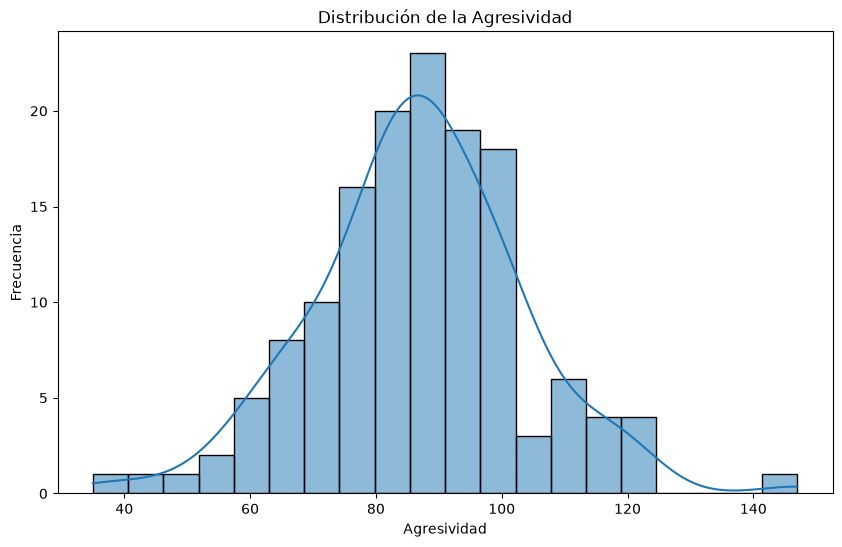

In [14]:
# creando un histograma para el nivel de agresividad
plt.figure(figsize=(10, 6))
sns.histplot(video_games['Agresividad'], bins=20, kde=True)
plt.title('Distribución de la Agresividad')
plt.xlabel('Agresividad')
plt.ylabel('Frecuencia')
plt.show()


Veamos ahora cómo cambia la distribición de la agresividad con otras variables en nuestra base de datos:

In [15]:
video_games.columns

Index(['Timestamp', 'What is your age?', 'Gender', 'Class',
       'City/ Residencial status', 'Type of Family',
       'What type of video games do you typically play?',
       'Name the video game you usually play ',
       'How many hours do you play Video Games in  a day?',
       'How much time do you play "violent" video games specifically?',
       'What changes on behaviour have you experienced in yourself after playing violent video games?',
       'Some of my Friends think I am hothead',
       'If I have to resort to violence to protect my rights, I will',
       'When people are especially nice to me, I wonder what they want',
       'I tell my friends openly when I disagree with them',
       'Once I became so mad, I broke things',
       'When people disagree with me I get into arguments',
       'When I argue I use abusive language', 'I am a hot-tempered person',
       'I am suspicious of strangers who are too friendly',
       'I have threatened some people whom I know

In [16]:
video_games['Type of Family'].unique()

<StringArray>
['nuclear', 'joint', 'extended']
Length: 3, dtype: str

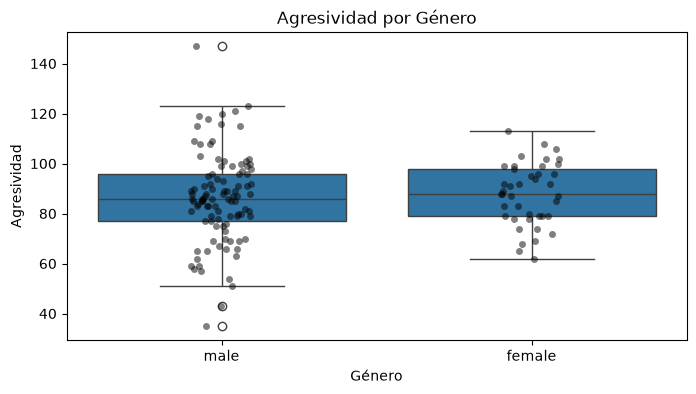

In [17]:
# gráfica de dependencia de agresividad y género
plt.figure(figsize=(8, 4))
sns.boxplot(x='Gender', y='Agresividad', data=video_games)
sns.stripplot(x='Gender', y='Agresividad', data=video_games, color='black', alpha=0.5)
plt.title('Agresividad por Género')
plt.xlabel('Género')
plt.ylabel('Agresividad')
plt.show()

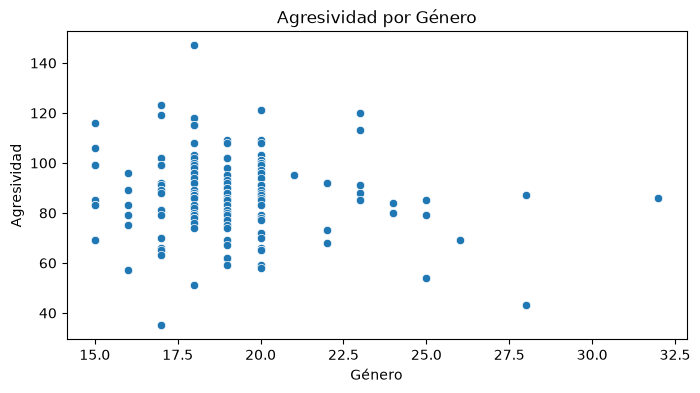

In [18]:
# Extraemos la edad de los jugadores usando regex
video_games['edad'] = video_games['What is your age?'].str.extract(r'(\d+)').astype(int)
# gráfica de dependencia de agresividad y edad
plt.figure(figsize=(8, 4))
sns.scatterplot(x='edad', y='Agresividad', data=video_games)
plt.title('Agresividad por Género')
plt.xlabel('Género')
plt.ylabel('Agresividad')
plt.show()

Text(0, 0.5, 'Agresividad')

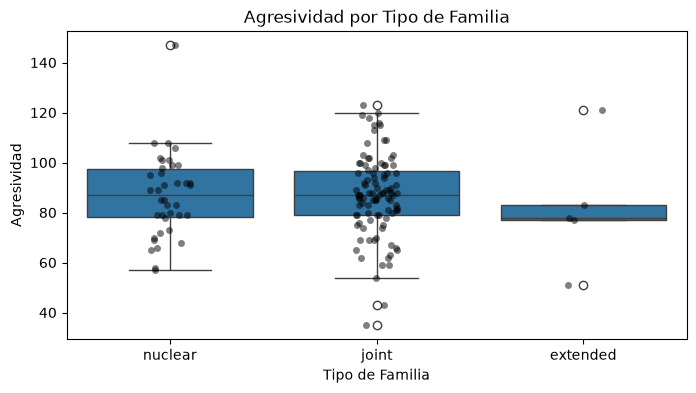

In [19]:
# gráfica de dependencia de agresividad y tipo de familia
plt.figure(figsize=(8, 4))
sns.boxplot(x='Type of Family', y='Agresividad', data=video_games)
sns.stripplot(x='Type of Family', y='Agresividad', data=video_games, color='black', alpha=0.5)
plt.title('Agresividad por Tipo de Familia')
plt.xlabel('Tipo de Familia')
plt.ylabel('Agresividad')


([0, 1, 2, 3, 4],
 [Text(0, 0, 'less than 1 hour'),
  Text(1, 0, 'more than 1 hour'),
  Text(2, 0, 'more than 2 hour'),
  Text(3, 0, 'more than 3 hour'),
  Text(4, 0, 'more than 5 hour')])

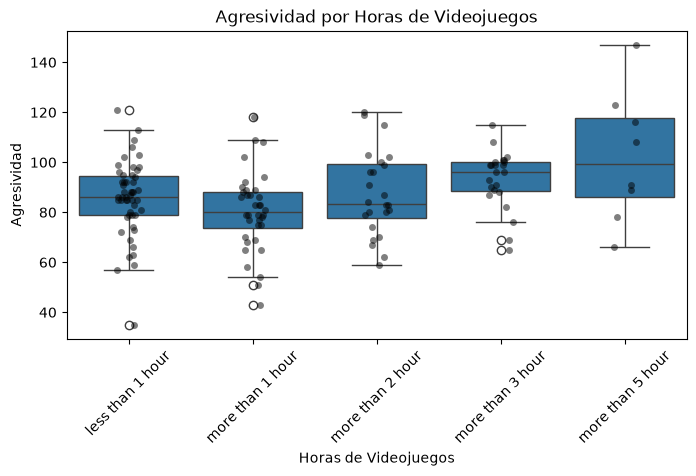

In [20]:
# gráfica de dependencia de agresividad y horas de videojuegos
plt.figure(figsize=(8, 4))
sns.boxplot(x='How many hours do you play Video Games in  a day?', y='Agresividad', data=video_games, order=['less than 1 hour', 'more than 1 hour', 'more than 2 hour', 'more than 3 hour', 'more than 5 hour'])
sns.stripplot(x='How many hours do you play Video Games in  a day?', y='Agresividad', data=video_games, color='black', alpha=0.5, order=['less than 1 hour', 'more than 1 hour', 'more than 2 hour', 'more than 3 hour', 'more than 5 hour'])
plt.title('Agresividad por Horas de Videojuegos')
plt.xlabel('Horas de Videojuegos')
plt.ylabel('Agresividad')
# rotamos las etiquetas del eje x
plt.xticks(rotation=45)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'less than 1 hour'),
  Text(1, 0, 'more than 1 hour'),
  Text(2, 0, 'more than 2 hour'),
  Text(3, 0, 'more than 3 hour'),
  Text(4, 0, 'more than 5 hour')])

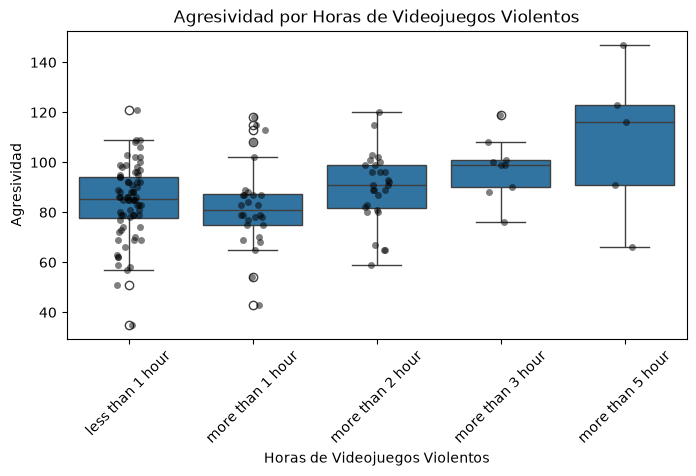

In [21]:
# gráfica de dependencia de agresividad y horas de videojuegos violentos
plt.figure(figsize=(8, 4))
sns.boxplot(x='How much time do you play "violent" video games specifically?', y='Agresividad', data=video_games, order=['less than 1 hour', 'more than 1 hour', 'more than 2 hour', 'more than 3 hour', 'more than 5 hour'])
sns.stripplot(x='How much time do you play "violent" video games specifically?', y='Agresividad', data=video_games, color='black', alpha=0.5, order=['less than 1 hour', 'more than 1 hour', 'more than 2 hour', 'more than 3 hour', 'more than 5 hour'])
plt.title('Agresividad por Horas de Videojuegos Violentos')
plt.xlabel('Horas de Videojuegos Violentos')
plt.ylabel('Agresividad')
# rotamos las etiquetas del eje x
plt.xticks(rotation=45)

## ANOVA (Análisis de varianzas)

ANOVA (Analysis of Variance) es una prueba estadística que se utiliza para determinar si existen diferencias significativas entre las medias de tres o más grupos independientes. Su objetivo principal es analizar si una variable categórica tiene un efecto sobre una variable continua. Se puede interpretar como una extención de la prueba t-test a más de dos muestras.

Se usa, por ejemplo, para responder preguntas como: “¿varía el nivel de alcohol entre vinos de diferentes calidades?” o “¿hay diferencia en el rendimiento de estudiantes según el método de enseñanza?”. Si el resultado del ANOVA es significativo (p < 0.05), indica que al menos un grupo tiene una media distinta, lo que se puede explorar más con pruebas post-hoc.

Antes de aplicar ANOVA, se deben verificar los siguientes supuestos:

- Normalidad de los datos (por grupo) → prueba de Shapiro-Wilk.

- Homogeneidad de varianzas → prueba de Levene.

- Independencia de las observaciones.

Hagamos primero un One-Way ANOVA, el cual se utiliza cuando quieres comparar las medias de una sola variable continua en función de una sola variable categórica con tres o más niveles (grupos). 

- Agresividad: Variable continua
- Tiempo jugando videojuegos violentos: Variable categórica --> 5 niveles (Tipos de datos categóricos, horas de juegos)


In [22]:
# Debido a que haremos primero un análisis sencillo, no es necesario usar toda la base de datos sino solo los datos que no son de utilidad
d_oneway = video_games.iloc[:,[9, -2]]
d_oneway

,"How much time do you play ""violent"" video games specifically?",Agresividad
99,more than 5 hour,147
19,more than 5 hour,123
46,less than 1 hour,121
118,more than 2 hour,120
104,more than 3 hour,119
...,...,...
101,less than 1 hour,57
85,more than 1 hour,54
9,less than 1 hour,51
109,more than 1 hour,43


Renombremos nuestra columna de tiempo jugado para que sea más fácil acceder a ella. En este tipo de análisis se recomienda renombrar las columnas con nombre sin espacios ya que pueden afectar el modelo

In [23]:
d_oneway = d_oneway.rename(columns={'How much time do you play "violent" video games specifically?': 'tiempo_juegos_violentos'})
d_oneway

,tiempo_juegos_violentos,Agresividad
99,more than 5 hour,147
19,more than 5 hour,123
46,less than 1 hour,121
118,more than 2 hour,120
104,more than 3 hour,119
...,...,...
101,less than 1 hour,57
85,more than 1 hour,54
9,less than 1 hour,51
109,more than 1 hour,43


### Validación de supuestos
El modelo ANOVA supone que la variable numérica está normalmente distribuida en cada categoría de la variable categórica, y también que la varianza de estas distribuciones es similar en todos los grupos. Como hicimos anteriormente podemos usar los test de Shapiro-Wilk y Levene, respectivamente, para probar estas condiciones.

In [24]:
# Normalidad
values = d_oneway['tiempo_juegos_violentos'].unique()

for value in values:
    mask = d_oneway['tiempo_juegos_violentos'] == value
    grupo = d_oneway[mask]['Agresividad']
    stat, p = shapiro(grupo)
    print(f"Grupo {value} - p = {p:.4f}") # p<0.05 indica que la normalidad no se cumple

Grupo more than 5 hour - p = 0.9422
Grupo less than 1 hour - p = 0.2506
Grupo more than 2 hour - p = 0.3757
Grupo more than 3 hour - p = 0.8452
Grupo more than 1 hour - p = 0.1484


In [25]:
# Homogeneidad
# creamos una lista de datos para cada grupo
samples = [d_oneway[d_oneway['tiempo_juegos_violentos'] == value]['Agresividad'] for value in values]

# aplicamos la prueba de Levene
stat, p = levene(*samples)
print(f"Levene's test - p = {p:.4f}") # p<0.05 indica que la homogeneidad no se cumple

Levene's test - p = 0.1603


Como vemos, ni las pruebas de normalidad ni las de homogeneidad arrojan prueba suficiente como para rechazar las hipótesis nulas.

#### ANOVA con la librería `scipy`
Podemos entonces aplicar el ANOVA y analizar si los niveles de agresividad están relacionados con el tiempo de juego de juegos violentos.

In [26]:
from scipy.stats import f_oneway

f_stat, p_val = f_oneway(*samples)
print(f"F = {f_stat:.3f}, p = {p_val:.4f}")

F = 4.527, p = 0.0018


En ANOVA, la hipótesis nula establece que las medias de todos los grupos son iguales, es decir, que el nivel medio de agresividad es el mismo, independiente de la cantidad de horas diarias de juego. En este caso, al obtener un $p$-valor bajo, la hipótesis nula se puede rechazar y podemos concluir que el promedio de agresividad en al menos dos niveles de cantidad de horas de juego, tienen diferencias estadísticamente significativas.

#### ANOVA con `statsmodels`
Statsmodels es una librería estadística, y usualmente las implementaciones de modelos como ANOVA son más directas usando esta librería. Para este caso no tendremos que separar nuestras categorías, ya que la librería se encarga de hacerlo.

In [27]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

modelo = ols('Agresividad ~ C(tiempo_juegos_violentos)', data=d_oneway).fit()

Como se observa al llamar al modelo, el primer argumento que recibe es una especia de `string` el cual tiene como primer valor la variable dependiente, es decir, la que quiero explicar. El término `~`significa "es explicado por". Finalmente `C(Tiempo_jugado)` significa que estás definiendo la variable de tiempo como categórica y aquí se especifica la variable independiente

Ahora obtenemos nuestra tabla ANOVA que nos brinda información valiosa.

In [28]:
anova_tabla = sm.stats.anova_lm(modelo)
print(anova_tabla)

                               df        sum_sq      mean_sq         F  \
C(tiempo_juegos_violentos)    4.0   4545.751738  1136.437935  4.526524   
Residual                    137.0  34395.487698   251.061954       NaN   

                              PR(>F)  
C(tiempo_juegos_violentos)  0.001825  
Residual                         NaN  


Para este caso, como se esperaba, obtuvimos el mismo resultado de $p$-valor en la columna de `PR(>F)`, por lo que se llega a la misma conclusión. Sin embargo, statsmodels nos permite conocer en más detalle cuáles son las categorías que difieren entre sí.

In [29]:
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:            Agresividad   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     4.527
Date:              vie., 31 jul. 2026   Prob (F-statistic):            0.00183
Time:                        16:57:31   Log-Likelihood:                -591.27
No. Observations:                 142   AIC:                             1193.
Df Residuals:                     137   BIC:                             1207.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

La tabla se debe interpretar de la manera siguiente. Aunque inicialmente hay 5 posibles valores de tiempo de videojuegos violentos, en la tabla sólo aparecen 4, esto es porque uno de ellos ha sido tomado como referencia. En este caso la referencia es la correspondiente a `'less than 1 hour'`. Para esta categoría, el valor promedio de agresividad es el que se muestra en la columna `coef` de la fila `Intercept`.

En las filas siguientes, el valor de `coef` marca la desviación promedio de la agresividad en cada una de las otras categorías. Por ejemplo, las personas que juegan más de 2 horas, en promedio, tienen 5.2679 puntos adicionales en la agresividad. Las personas que juegan más de 5 horas tienen 24.22 puntos promedios adicionales en agresividad.

Sin embargo, estos valores se deben contrastar con la columna `P>|t|` que nos muestra el $p$-valor para cada coeficiente, esto es, la probabilidad de observar los datos asumiendo que el coeficiente es 0 (esta es la hipótesis nula). Así podemos determinar que las únicas categorías estadísticamente diferentes de la categoría de referencia (`'less than 1 hour'`) son `'more than 3 hour'` y `'more than 5 hour'`.

___
#### Ejercicio 1
Corra un modelo One-way ANOVA con la librería `scipy` para la variable de tiempo de juego en videojuegos, en general. ¿Existen diferencias significativas esta vez? Tenga en cuenta que usualmente se deben evaluar los supuestos.
___

In [30]:
# Solucion Ejercicio 1: One-way ANOVA para el tiempo de juego GENERAL (no solo violentos)
from scipy.stats import shapiro, levene, f_oneway

# La columna 8 es el tiempo de juego en videojuegos en general
col_general = video_games.columns[8]
d_oneway_gen = video_games[[col_general, 'Agresividad']].rename(columns={col_general: 'tiempo_general'})
valores = d_oneway_gen['tiempo_general'].unique()

# --- Normalidad (Shapiro por grupo) ---
print('--- Normalidad (Shapiro) ---')
for v in valores:
    grupo = d_oneway_gen[d_oneway_gen['tiempo_general'] == v]['Agresividad']
    stat, p = shapiro(grupo)
    print(f'{v}: n={len(grupo)}  p={p:.4f}')

# --- Homogeneidad (Levene) ---
samples = [d_oneway_gen[d_oneway_gen['tiempo_general'] == v]['Agresividad'] for v in valores]
stat, p_levene = levene(*samples)
print()
print('--- Homogeneidad (Levene) ---')
print(f'p = {p_levene:.4f}')

# --- One-way ANOVA (scipy) ---
F, p_val = f_oneway(*samples)
print()
print('--- One-way ANOVA (scipy) ---')
print(f'F = {F:.3f}, p = {p_val:.4f}')

--- Normalidad (Shapiro) ---
more than 5 hour: n=8  p=0.9512
less than 1 hour: n=51  p=0.0789
more than 2 hour: n=24  p=0.5413
more than 1 hour: n=36  p=0.5587
more than 3 hour: n=23  p=0.0848

--- Homogeneidad (Levene) ---
p = 0.0446

--- One-way ANOVA (scipy) ---
F = 4.360, p = 0.0024


**Respuesta Ejercicio 1.**

**Supuestos.** La **normalidad se cumple** en los 5 grupos (Shapiro p ≥ 0.05 en todos). La **homogeneidad es borderline**: Levene da p = 0.045, apenas por debajo de 0.05, así que las varianzas no son del todo homogéneas (violación leve).

**Resultado.** F = 4.360, **p = 0.0024**. Como **p < 0.05, sí existen diferencias significativas** en la agresividad según el tiempo de juego en videojuegos en general. El resultado es prácticamente el mismo que con los videojuegos violentos del ejemplo (F = 4.527, p = 0.0018).

**Robustez.** Como Levene fue borderline, se verificó con una **ANOVA de Welch** (robusta ante varianzas desiguales): F = 3.759, **p = 0.0117**, que también es significativa. Por lo tanto la conclusión es sólida pese a la leve heterogeneidad.

**Interpretación.** Las medias de agresividad **crecen con el tiempo de juego**: de ~86 puntos en quienes juegan menos de 1 hora a ~102 en quienes juegan más de 5 horas. Esto sugiere que, a mayor tiempo de juego (violento o no), mayor es la agresividad promedio reportada.

Ahora hagamos un Two-Way ANOVA, el cual permite evaluar:

- El efecto individual de cada factor sobre una variable dependiente continua.
- Si hay una interacción entre los dos factores (es decir, si el efecto de un factor depende del nivel del otro).

Se usa con una variable continua y dos categóricas.

Para nuestro caso las variables serán así:

- Puntaje encuesta: Variable continua
- Tiempo en videojuegos violentos: Variable categórica (5 niveles)
- Género: Variable categórica (2 niveles)

In [31]:
# Ahora nos quedaremos con las columnas de utilidad
d_twoway = video_games.iloc[:,[2, 9, -2]]
# Nuevamente renombramos las columnas necesarias
d_twoway = d_twoway.rename(columns={'How much time do you play "violent" video games specifically?': 'tiempo_juegos_violentos'})
d_twoway

,Gender,tiempo_juegos_violentos,Agresividad
99,male,more than 5 hour,147
19,male,more than 5 hour,123
46,male,less than 1 hour,121
118,male,more than 2 hour,120
104,male,more than 3 hour,119
...,...,...,...
101,male,less than 1 hour,57
85,male,more than 1 hour,54
9,male,less than 1 hour,51
109,male,more than 1 hour,43


## ANOVA de dos factores
Supongamos ahora que deseamos estudiar el efecto conjunto del tiempo de juego y del género sobre los niveles de agresividad. Agregar más variables al análisis permite llegar a resultados más específicos y mejor informados, sin embargo, usar demasiadas variables puede interferir en la capacidad del modelo para distinguir entre múltiples efectos y puede desestabilizarlo numéricamente.

Veamos cómo implementar el ANOVA de dos factores

In [32]:
modelo = ols('Agresividad ~ C(Gender) + C(tiempo_juegos_violentos) + C(Gender):C(tiempo_juegos_violentos)', data=d_twoway).fit()
# En esta caso la expresión C(Gender):C(Tiempo_jugado) es para tener en cuenta la interacción de las dos variables categóricas sobre la variable objetivo

En este caso estamos suponiendo que la agresividad depende de:
- El género
- El tiempo de juego de juegos violentos
- La interacción entre género y juegos violentos

El significado de esta interacción se verá más adelante.

In [33]:
anova_tabla = sm.stats.anova_lm(modelo)
print(anova_tabla)

                                         df        sum_sq      mean_sq  \
C(Gender)                               1.0     64.908599    64.908599   
C(tiempo_juegos_violentos)              4.0   5120.939673  1280.234918   
C(Gender):C(tiempo_juegos_violentos)    4.0   1019.958161   254.989540   
Residual                              133.0  33594.724597   252.591914   

                                             F    PR(>F)  
C(Gender)                             0.256970  0.613049  
C(tiempo_juegos_violentos)            5.068392  0.000783  
C(Gender):C(tiempo_juegos_violentos)  1.009492  0.404977  
Residual                                   NaN       NaN  


El genero afecta la  agresividad :  No (0.613) , numero  de horas de jugando videojuegos afecta la agresividad: Si(0.00078), Si la correlación entre el tiempo de videojuegos y la agresividad se ve modificada por el genero : No (0.404)

De acuerdo con los resultados de nuestr ANOVA de dos factores se ve que tanto el tiempo de juego como la interacción entre tiempo de juego y género son estadísticamente significativos a la hora de cuantificar la dependencia con los niveles de agresividad. Veamos ahora el análisis detallado del modelo:

In [34]:
# imprimimos el resumen del modelo
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:            Agresividad   R-squared:                       0.137
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     2.646
Date:              vie., 31 jul. 2026   Prob (F-statistic):             0.0100
Time:                        16:57:50   Log-Likelihood:                -589.60
No. Observations:                 142   AIC:                             1197.
Df Residuals:                     133   BIC:                             1224.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                                                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

De nuevo, lo primero que debemos hacer es ubicar cuáles son las categorías de referencia para cada variable. Tras una revisión, encontramos que las categorías de referencia son `mujer` y `menos de una hora de juego`. Así las cosas, el `coef` en la fila `Intercept` corresponde a la agresividad promedio para mujeres que juegan menos de una hora: 87.84. En la fila correspondiente a `Gender_male`, se encuentra el aumento promedio observado en hombres para la misma referencia en el tiempo de juego. Es decir, el -5.4331 indica que, en promedio, los hombres que juegan menos de una hora muestran 5.43 puntos menos de agresividad que las mujeres.

De la misma manera, los coeficientes correspondientes solo al tiempo de juego indican la variación esperada en agresividad, para las mujeres, cuando el tiempo de juego aumenta. Los términos de interacción corresponden a los aumentos **adicionales** esperados en los niveles de agresividad al cambiar tanto el género como los niveles de juego diarios. De nuevo, los $p$-valor nos muestran que hay aumentos significativos de niveles de agresividad en los hombres y mujeres que juegan más de 5 horas al día.

Verifiquemos ahora si los supuestos se satisfacen

In [35]:
# Normalidad
shapiro_test = shapiro(modelo.resid)
print("Shapiro-Wilk p-value:", shapiro_test.pvalue)

Shapiro-Wilk p-value: 0.05049599309700265


In [36]:
# Homocedasticidad
# Crear las combinaciones de grupos
grupos = d_twoway.groupby(['Gender', 'tiempo_juegos_violentos'])['Agresividad'].apply(list)
resultado_levene = levene(*grupos)
print("Levene p-value:", resultado_levene.pvalue)

Levene p-value: 0.22818714723166614


Hay un tema que debe preocuparnos, y es que hay dos filas en los resultados del ANOVA con exactamente los mismos resultados. Esto es altamente inusual y nos puede indicar que hay algún problema con el modelo. Revisemos si hay datos en todas las categorías:

In [37]:
d_twoway.groupby(['tiempo_juegos_violentos', 'Gender']).count()

Agresividad
tiempo_juegos_violentos Gender             
less than 1 hour        female           26
                        male             46
more than 1 hour        female           11
                        male             17
more than 2 hour        female            3
                        male             25
more than 3 hour        female            1
                        male              8
more than 5 hour        male              5

En efecto, no hay datos para mujeres jugando más de 5 horas diarias. Esta es la razón para el resultado extraño y nos obliga a revisar con cuidado nuestro análisis. Sin embargo, en últimas, las conclusiones no cambian. **Existe una relación estadísticamente significativa entre las horas diarias de juego y los niveles de agresividad**. Sin embargo, nuestro análisis **NO PUEDE DAR INFORMACIÓN DE CAUSALIDAD. No podemos concluir si la gente juega más por ser agresiva, o es agresiva porque juega más**

Una vez validadas nuestro modelo ANOVA podemos explicar porque obtenemos resultados diferentes para una misma columna en un One-way y un Two-way ANOVA. Esto puede estar ocurriendo por las siguientes razones:

- Cuando añades un segundo factor `Gender` y su interacción con `Tiempo_jugado`, el modelo distribuye la variación explicada entre estos nuevos términos. Es posible que parte del efecto que antes se atribuía a Tiempo_jugado ahora se esté explicando mejor por la interacción.

- El modelo más complejo tiene menos poder para detectar efectos principales. En modelos con más factores e interacciones, el número de grados de libertad disponibles disminuye, y esto puede afectar la significancia estadística, especialmente si el tamaño de muestra no es muy grande.

- Desbalance: Si tus datos no están bien balanceados (por ejemplo, diferentes cantidades de participantes por combinación de género y tiempo jugado), eso puede influir en los resultados. A veces, el efecto aparente en el modelo simple se debe a diferencias entre grupos que desaparecen cuando se controla por otro factor.

___
#### Ejercicio 4
Realice una análisis de varianzas ANOVA para determinar si existen diferencias significativas en el puntaje de la encuesta de videojuegos al analizar los niveles de estudio y tiempo jugado.
____

**Nota previa: limpieza de la variable de nivel de estudio.** La columna Class es texto libre y llego con **48 categorias distintas**, la mayoria con una sola observacion (ej. "Bscs 1st semester", "BBA 4th sem", "14", "16"). Usarla tal cual produciria un ANOVA con celdas vacias o casi vacias, poco confiable. Para poder cruzarla con el tiempo de juego, se consolido en dos niveles amplios y defendibles:

- **Escolar**: 9th, 10th, 11th, 12th (aun en colegio)
- **Superior**: todo lo demas (Bachelor, Master, Uni, Job, Diploma, etc. -- ya graduados de colegio)

In [38]:
# Solucion Ejercicio 4: ANOVA de dos factores (nivel de estudio x tiempo de juego)
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Consolidamos Class en dos niveles amplios (ver nota anterior)
escolar = {"9th", "10th", "11th", "12th"}
video_games["nivel_estudio"] = np.where(video_games["Class"].isin(escolar), "Escolar", "Superior")

# Reutilizamos la columna general de tiempo de juego (la misma del Ejercicio 1)
col_tiempo = video_games.columns[8]
d_ej4 = video_games[["nivel_estudio", col_tiempo, "Agresividad"]].rename(columns={col_tiempo: "tiempo_juego"})

# Verificamos que no haya combinaciones vacias antes de ajustar el modelo
print(d_ej4.groupby(["nivel_estudio", "tiempo_juego"]).size().unstack(fill_value=0))

# Modelo de dos factores con interaccion
modelo_ej4 = ols("Agresividad ~ C(nivel_estudio) + C(tiempo_juego) + C(nivel_estudio):C(tiempo_juego)", data=d_ej4).fit()
anova_ej4 = sm.stats.anova_lm(modelo_ej4)
print()
print(anova_ej4.round(4))

tiempo_juego   less than 1 hour  more than 1 hour  more than 2 hour  \
nivel_estudio                                                         
Escolar                      26                25                20   
Superior                     25                11                 4   

tiempo_juego   more than 3 hour  more than 5 hour  
nivel_estudio                                      
Escolar                      19                 5  
Superior                      4                 3  

                                     df      sum_sq    mean_sq       F  PR(>F)
C(nivel_estudio)                    1.0     51.8930    51.8930  0.2086  0.6487
C(tiempo_juego)                     4.0   4355.2037  1088.8009  4.3757  0.0024
C(nivel_estudio):C(tiempo_juego)    4.0   1688.9350   422.2338  1.6969  0.1545
Residual                          132.0  32845.2077   248.8273     NaN     NaN


**Respuesta Ejercicio 4.**

Resultados de la tabla ANOVA de dos factores:

| Factor | F | p-valor | ¿Significativo? |
|---|---|---|---|
| Nivel de estudio | 0.209 | 0.649 | No |
| Tiempo de juego | 4.376 | **0.0024** | **Si** |
| Interaccion (nivel x tiempo) | 1.697 | 0.155 | No |

Conclusiones:

1. **El tiempo de juego SI produce diferencias significativas** en el puntaje de agresividad (p=0.0024), consistente con el resultado del Ejercicio 1.
2. **El nivel de estudio, por si solo, NO produce diferencias significativas** (p=0.649): estudiantes de colegio y de nivel superior tienen, en promedio, niveles de agresividad similares.
3. **No hay interaccion significativa** (p=0.155): el efecto del tiempo de juego sobre la agresividad es, estadisticamente, el mismo sin importar el nivel de estudio (aunque en los promedios por celda se ve algo de variacion, especialmente en "Superior" con pocos datos en horas intermedias, la interaccion no alcanza significancia).

**En resumen:** de los dos factores, solo el **tiempo de juego** explica diferencias reales en la agresividad; el nivel de estudio no aporta un efecto propio ni modifica el efecto del tiempo de juego.

In [39]:
print(modelo_ej4.summary())

                            OLS Regression Results                            
Dep. Variable:            Agresividad   R-squared:                       0.157
Model:                            OLS   Adj. R-squared:                  0.099
Method:                 Least Squares   F-statistic:                     2.722
Date:              vie., 31 jul. 2026   Prob (F-statistic):            0.00607
Time:                        16:58:13   Log-Likelihood:                -587.99
No. Observations:                 142   AIC:                             1196.
Df Residuals:                     132   BIC:                             1226.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

**Como leer los cruces de esta tabla.**

El modelo tiene una categoria de **referencia** para cada factor (la que no aparece explicita): `nivel_estudio = Escolar` y `tiempo_juego = less than 1 hour`. El `Intercept` (83.42) es la media estimada de esa celda base (Escolar + menos de 1 hora), que coincide con el promedio real de esa combinacion.

Las filas se agrupan en tres bloques:

1. **Efecto principal de nivel_estudio** (`C(nivel_estudio)[T.Superior]`, coef=4.62, p=0.298): cuanto cambia la agresividad promedio al pasar de Escolar a Superior, **manteniendo fijo** el tiempo de juego en la categoria base (menos de 1 hora). No es significativo.

2. **Efecto principal de tiempo_juego** (`C(tiempo_juego)[T.more than X hour]`): cuanto cambia la agresividad al pasar de "menos de 1 hora" a cada categoria de mas tiempo, **dentro del grupo Escolar**. Solo el ultimo salto es significativo: `more than 5 hour` (coef=16.98, p=0.029) — jugar mas de 5 horas si eleva la agresividad frente a jugar menos de 1 hora, en estudiantes de colegio.

3. **Los cruces / interaccion** (`C(nivel_estudio)[T.Superior]:C(tiempo_juego)[T.more than X hour]`): esta es la parte clave para entender "los cruces". Cada fila responde: *¿el efecto de jugar X horas (vs. menos de 1 hora) es DIFERENTE en Superior comparado con Escolar?* Se interpreta como un ajuste que se SUMA al efecto principal cuando ambas condiciones se cumplen a la vez (Superior Y esa categoria de tiempo). Por ejemplo, `Superior:more than 1 hour` = -16.25 (p=0.026, significativo) significa: el salto de "menos de 1h" a "mas de 1h" que en Escolar practicamente no cambia nada (+0.58), en Superior se vuelve fuertemente negativo (0.58 - 16.25 = -15.7 puntos) — es decir, en el grupo Superior, jugar un poco mas (1-2h) se asocia a MENOS agresividad que jugar menos de 1h, mientras que en Escolar no hay diferencia.

**¿Por que este cruce individual da significativo pero la interaccion global del Ejercicio 4 no (p=0.155)?** Porque la tabla ANOVA (`anova_lm`) prueba si el conjunto completo de 4 terminos de interaccion aporta algo en bloque, mientras que el `summary()` prueba cada coeficiente por separado. Con muestras pequeñas en varias celdas (ej. Superior + mas de 1 hora solo tiene 11 casos), es facil que un termino individual salga "significativo" por azar sin que el patron de interaccion completo sea consistente. La prueba conjunta (ANOVA) es la que se debe usar para la conclusion general; los coeficientes individuales del `summary()` sirven para explorar el detalle, no para sacar conclusiones aisladas.

___
#### Ejercicio 5
Evalue los supuestos del modelo ANOVA usado en el ejericio anterior. ¿Se puede confiar en los resultados del modelo ANOVA?
____

In [ ]:
# Solucion Ejercicio 5: validacion de supuestos del modelo del Ejercicio 4
from scipy.stats import shapiro, levene

# Normalidad de los RESIDUOS del modelo (no de la variable original)
stat, p_norm = shapiro(modelo_ej4.resid)
print(f"Normalidad (Shapiro sobre residuos): p = {p_norm:.4f}")

# Homogeneidad de varianzas entre las 10 combinaciones nivel_estudio x tiempo_juego
grupos = [g['Agresividad'].values for _, g in d_ej4.groupby(['nivel_estudio', 'tiempo_juego'])]
stat, p_lev = levene(*grupos)
print(f"Homogeneidad (Levene sobre las 10 celdas): p = {p_lev:.4f}")

**Respuesta Ejercicio 5.**

| Supuesto | Prueba | p-valor | Resultado |
|---|---|---|---|
| Normalidad de residuos | Shapiro-Wilk | 0.530 | Se cumple (p >= 0.05) |
| Homogeneidad de varianzas | Levene (10 celdas) | 0.288 | Se cumple (p >= 0.05) |

**Si, se puede confiar en los resultados del ANOVA del Ejercicio 4.** A diferencia del ejemplo del One-Way ANOVA con tiempo de juegos violentos (donde ni normalidad ni homogeneidad se cumplian), aqui **ambos supuestos se satisfacen claramente**: los residuos del modelo son normales y las 10 combinaciones de nivel_estudio x tiempo_juego tienen varianzas comparables entre si. Esto respalda directamente la conclusion del Ejercicio 4: el efecto significativo del tiempo de juego (p=0.0024) y la ausencia de efecto del nivel de estudio y de la interaccion son resultados confiables, no artefactos de una violacion de supuestos.

In [ ]:
print(modelo_ej4.summary())

# Conclusión

El desarrollo de este caso permitió aplicar y comparar distintas herramientas estadísticas en Python para la implementación del ANOVA, tanto de un factor como de dos factores. Utilizando la función f_oneway de scipy.stats, se exploraron diferencias entre grupos en función del tiempo de juego, mientras que con statsmodels se ajustaron modelos más complejos que incluyeron interacciones entre variables como el género y el tiempo de exposición a videojuegos. Estas herramientas facilitaron no solo la ejecución del análisis, sino también la validación de supuestos y la interpretación detallada de los efectos. El uso de scipy y statsmodels brinda una base sólida para el análisis estadístico en estudios de comportamiento, permitiendo extraer conclusiones significativas a partir de datos categóricos y continuos.

### Origen de los datos

- Efecto de los videojuegos en el comportamiento agresivo https://www.kaggle.com/datasets/muhammadshamoeel/effects-of-video-games-on-aggression-msdos-csv/data 
